ADD EXCEPTIONS AND WHILE LOOP IN ALL PROCESSES THAT INVOLVES USER INPUT
    
data import - ✅
check if the uploaded dataset is a xlxs or csv file - ✅
give a summary of the dataset - ✅
remove any outliers ( winzorisation ) - ✅ 
checking for duplicates and removing - ✅ 
input target seperation - ✅ 
check if the target column is Numeric, binary or categorical - ✅
if regression: - ✅
    data type =  int/ float
    unique values >20
    unique ratio >0.5
    user confirmation
if classification: - ✅
    data type = object, Int
    unique values < 20
    unique ratio < 0.5
    if object : 
        encode them into integer and create a dictinary to store matching values
    user confirmation
if its object and has 20 + unique values - say the target column is invalid - ✅

ask for the ML Type ( regression or classification )
if regression:
    convertion of categorical data into numeric
    use feature importance to remove cols if theres too much
    split into train and test data 
    checking of missing data and filling it
    use all the regressors provided 
    find the best model
    provide the the model through joblib
    ask input if theres a need to predict
    thanks

if classifier:
    check for class imbalance 
    convertion of categorical data into numeric
    use feature importance to remove cols if theres too much
    checking of missing data and filling it
    standardisation ( standard scaler)
    split into train and test data ( stratified k fold ) 
    if class imbalance:
        use Smote on training data alone to stabilize
    use all the classifiers provided 
    find the best model
    provide the the model and scaler through joblib
    ask input if theres a need to predict
    thanks

filepath = "D:\COLLEGE\heart.csv" - classification
filepath = "D:\COLLEGE\Linear Regression - Sheet1.csv" - regression

In [1]:
#IMPORTING THE NECESSARY LIBRARIES..!
import pandas as pd
import numpy as np
import Data_ingestion
from Summary_of_data import summary_of_data
from Outlier_handling import handling_outliers
from Duplicate_removal import remove_duplicates
from Visualisation import visual_Module
from Target_separator import input_output_separator
from Target_tester import target_tester
from Regression import reg_model
from Classification_scaling import Cls_model
from Classification_model import cls_model_train
from Prediction import predict

In [2]:
import joblib

WELCOME TO DATAFORGE..!!!



Give the path to the dataset that you want to be processed (enclose it within quotes):
 "D:\COLLEGE\Linear Regression - Sheet1.csv"




The Dataset has been successfully uploaded, here's a short preview..!


   X         Y
0  1  3.888889
1  2  4.555556
2  3  5.222222
3  4  5.888889
4  5  6.555556

The dataset has 300 rows and 2 columns.

The column names are : ['X', 'Y']

The missing values in each attributes are shown below...!

X    0
Y    0
dtype: int64

The dataset has 0 duplicate values.

Other things you may want a look into : 

                X           Y
count  300.000000  300.000000
mean   150.500000  102.215556
std     86.746758   57.842711
min      1.000000    1.888889
25%     75.750000   52.388889
50%    150.500000  102.222222
75%    225.250000  152.055556
max    300.000000  201.888889


The Outliers in the dataset have been successfully dealt with by DataForge( if there was any..! )


DataForge Removed 0 duplicate rows.


A Histogram of the given dataset is given below..



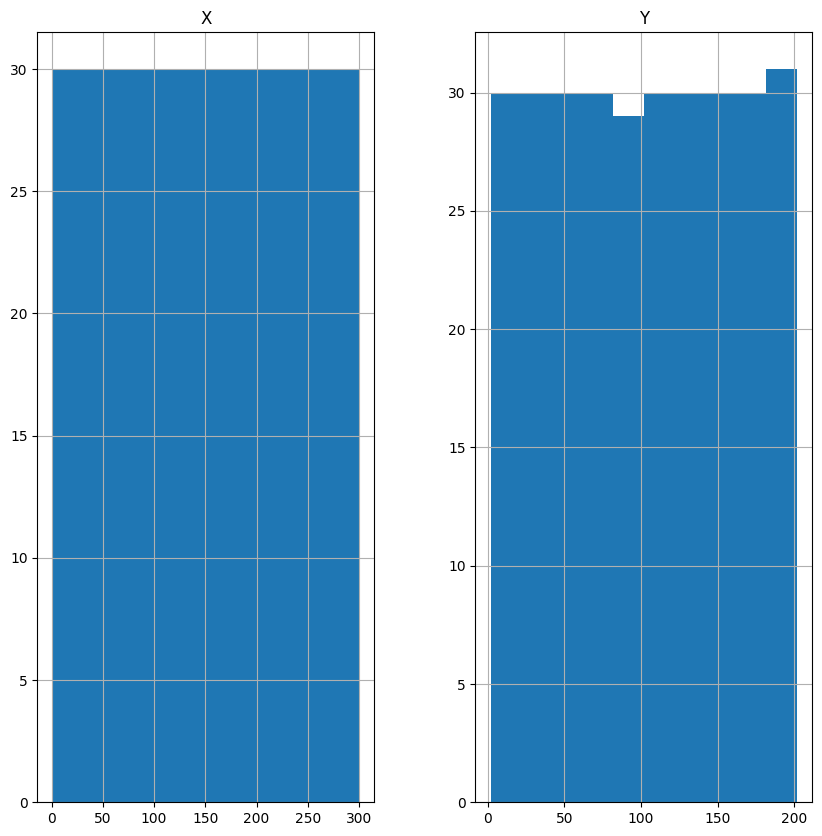


A Heatmap of the given dataset is given below..



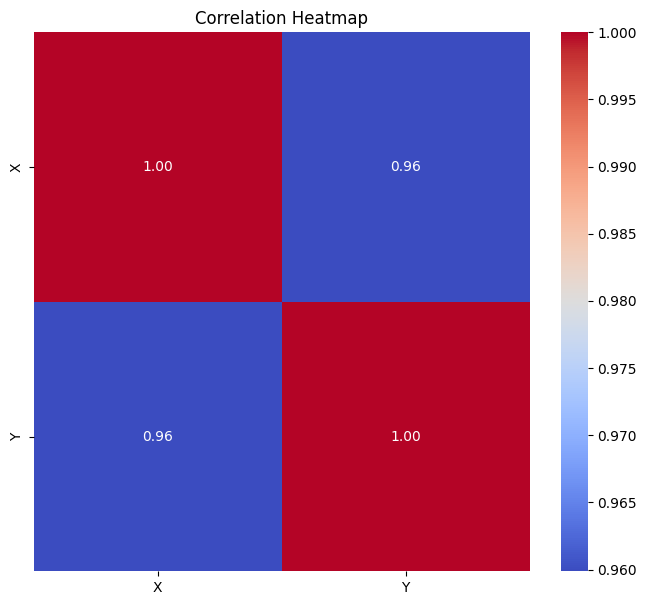

Now for the next part, Correctly type the output column's name :
 Y


DataForge has successfully seperated the dataset into input and target data..!

--------------------------------------------------


Enter the type of ML algorithm you want to perform (Regression / Classification) : (R / C):  r


DataForge will now proceed to process the data for ML processes
-------------------------------------------------------
Linear regression's accuracy : 0.997
Random forest regressor's accuracy: 0.985
Gradient boost regressor's accuracy: 1.0.



Which model do you want to save and deploy? Enter 1, 2, or 3:  3


...


Do you want to make another prediction? (Y/N):  y


✅ Dataforge has successfully loaded your saved model..

Dataforge will now take your input values for prediction..
(For categorical columns, enter the raw text e.g 'Male', 'Red' etc.)



  Enter value for 'X':  5


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(



  🎯 Predicted Value  : 6.5863


In [ ]:
data = Data_ingestion.data_ingestion()
summary_of_data(data)
data_without_outliers = handling_outliers(data)
cleaned_data = remove_duplicates(data_without_outliers)
visual_Module(cleaned_data)
input_data, target = input_output_separator(cleaned_data)
Model, label_encoder = target_tester(target)
if Model == "r":
    best_model, model_name, original_columns, feature_names = reg_model(input_data, target)
    model_save = ""
    while model_save not in ["y","n"]:
        model_save = input("Do you want to save the selected model and for further predictions..?:(Y/N)").lower()
        if model_save not in ["y","n"]:
            print("Please give a proper input:(Y/N)..!\n")
    if model_save == "y":
        joblib.dump(best_model, "dataforge_model.pkl")
        joblib.dump(feature_names, "dataforge_features.pkl")
        joblib.dump(original_columns, "dataforge_original_cols.pkl")
        print(f"✅ {model_name} has been saved successfully as 'dataforge_model.pkl'.")
        
elif Model == "c":
    X_train, X_test, Y_train, Y_test, Scaler, feature_names, original_columns = Cls_model(input_data, target )
    Best_model, Model_name = cls_model_train(X_train, X_test, Y_train, Y_test, Scaler)

    model_save = ""
    while model_save not in ["y","n"]:
        model_save = input("Do you want to save the selected model and for further predictions..?:(Y/N)").lower()
        if model_save not in ["y","n"]:
            print("Please give a proper input:(Y/N)..!\n")
    if model_save == "y":
        joblib.dump(Best_model, "dataforge_model.pkl")
        joblib.dump(Scaler, "dataforge_scaler.pkl")
        joblib.dump(feature_names, "dataforge_features.pkl")
        joblib.dump(original_columns, "dataforge_original_cols.pkl")
        if label_encoder is not None:
            joblib.dump(label_encoder,"dataforge_Lbl_edr.pkl")
        print(f"✅ {Model_name} and scaler have been saved successfully as 'dataforge_model.pkl' and 'dataforge_scaler.pkl'")
predict(Model)